[*********************100%***********************]  3 of 3 completed


--- Data successfully loaded into a Vector Space ---
Vector dimensions: (365, 3) (Days x Assets)
Ticker            AAPL       BTC-USD       GOLD
Date                                           
2024-01-02  183.731277  44957.968750  27.755003
2024-01-03  182.355591  42848.175781  26.896795
2024-01-04  180.039688  44179.921875  27.604115
2024-01-05  179.317154  44162.691406  27.490942
2024-01-06  179.317154  43989.195312  27.490942


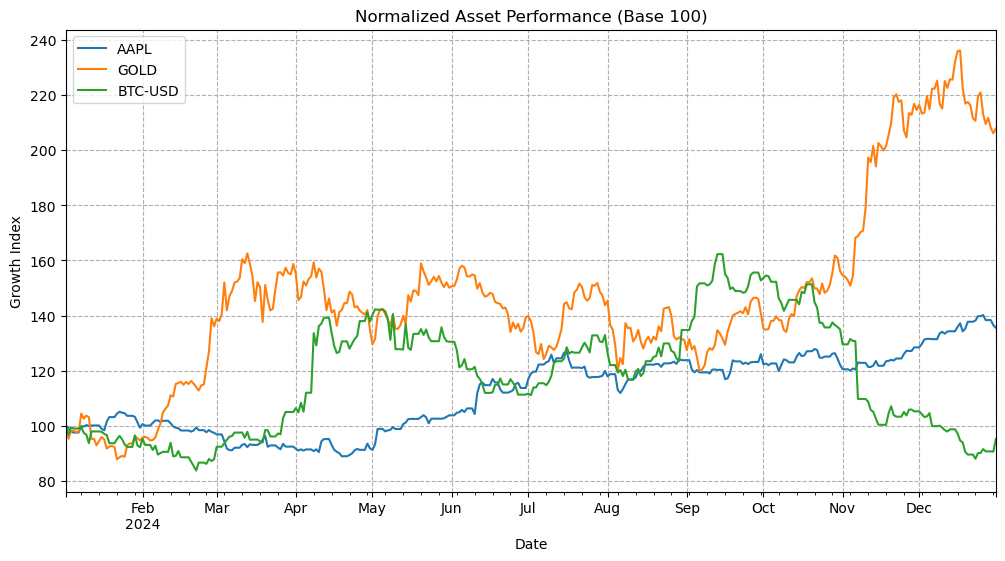

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


assets = ['AAPL', 'GOLD', 'BTC-USD'] 

def download_data(tickers, start_date="2024-01-01", end_date="2025-01-01"):
    """
    Fetches historical price data. 
    Using auto_adjust=True to ensure 'Close' represents the Adjusted price.
    Reference: yfinance documentation (https://pypi.org)
    """
    print(f"Downloading data for: {tickers}...")
    # auto_adjust=True handles the 'Adj Close' vs 'Close' issue automatically
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
    
    # Extract only the 'Close' column group
    return data['Close']


df = download_data(assets)


if df.empty:
    print("Error: No data downloaded. Check your internet connection or tickers.")
else:
    df = df.ffill().dropna() 
    print("\n--- Data successfully loaded into a Vector Space ---")
    print(f"Vector dimensions: {df.shape} (Days x Assets)")
    print(df.head())

    # Since BTC is $60k and GOLD is $2k, we normalize to start at 100 
    # to compare their "Rate of Change" (Calculus prep)
    df_normalized = (df / df.iloc[0]) * 100  
    df_normalized.plot(figsize=(12, 6))
    plt.title("Normalized Asset Performance (Base 100)")
    plt.xlabel("Date")
    plt.ylabel("Growth Index")
    plt.legend(assets)
    plt.grid(True, linestyle='--')
    plt.show()